In [1]:
import sys
import os
os.chdir("/home/karlandersson/Programming/MasterThesisProject")
print(os.getcwd())

/home/karlandersson/Programming/MasterThesisProject


In [2]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

from utils.solver import Solver
from utils.iso_reactor_utils import generate_config, generate_config_seq, plot_reactor_solutions, plot_reactor_temperature_schematic
from utils.interpolator import OpenMCTallyGridSurrogate

from coupled.iso_reactor import Reactor

Mesh warning: N_Z changed from 50 to 46
Mesh warning: Neutronics N_Z changed from 50 to 30
Mesh warning: N_R changed from 15 to 65


In [3]:
with open("./data/reactor_data.json", "r") as f:
    data = json.load(f)
    data["HeatPipe"]["material"]["h_cond"] = 550

MODEL_PATH = Path("./utils/rgi_surrogate.joblib")
interpolator_model = OpenMCTallyGridSurrogate()
interpolator_model = interpolator_model.load(MODEL_PATH)

In [4]:
Ns = [15, 65, 40]
cfg = generate_config(data, *Ns)
cfg_interp = generate_config(data, *Ns)

reactor = Reactor(cfg)

reactor_interp = Reactor(cfg_interp)
reactor_interp.set_interpolator_model(interpolator_model)

solver = Solver([reactor, reactor_interp], iterate=True)
solver.fsolve()

Mesh warning: N_Z changed from 40 to 46
Mesh warning: Fuel pin N_Z changed from 18 to 30
Mesh warning: Neutronics N_Z changed from 18 to 30
Mesh warning: N_Z changed from 40 to 46
Mesh warning: Fuel pin N_Z changed from 18 to 30
Mesh warning: Neutronics N_Z changed from 18 to 30
Running iteration 1 ...
fsolve message: The solution converged.
Running iteration 2 ...
fsolve message: The solution converged.


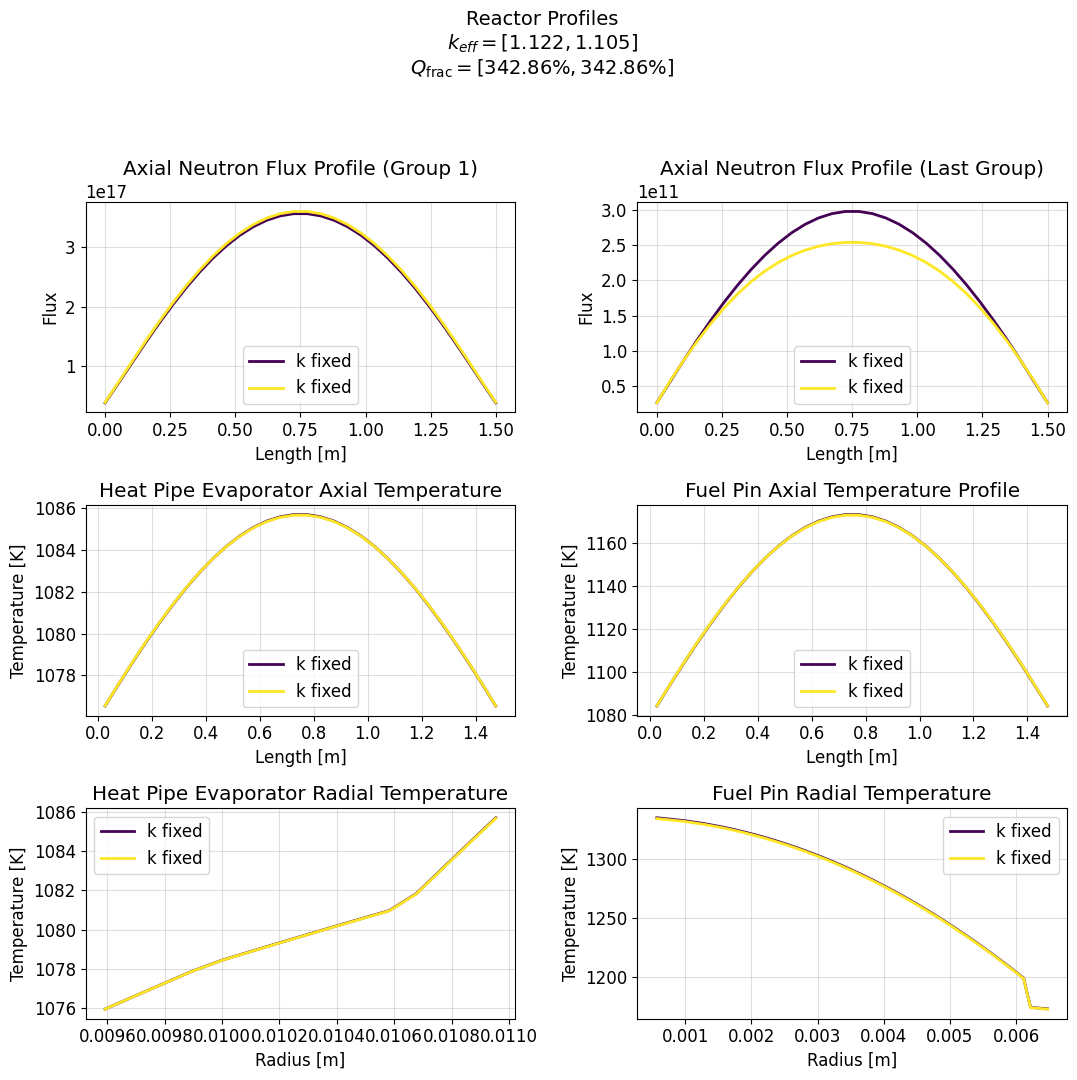

In [5]:
plot_reactor_solutions(solver)